# RMSSD Validation: PPG vs ECG

This notebook compares RMSSD calculated from our PPG sensor against an ECG sensor (BrainFlow) recorded from the same person at the same time.

**Workflow:**
1. Load PPG data from `ppg_data.txt` and ECG data from an Excel file
2. Skip the first `START_OFFSET_SEC` seconds of both recordings
3. Trim both signals to `RMSSD_DURATION_SEC` seconds
4. Process each signal with NeuroKit2 to detect peaks
5. Calculate RMSSD from each signal
6. Compare with absolute error

In [1]:
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURATION — Change these as needed
# ============================================================
PPG_PATH = "validation_data/ppg_data2.txt"                                    # Path to PPG sensor data (one value per line)
ECG_EXCEL_PATH = "validation_data/BrainFlow-RAW_2026-04-02_01-40-52_0.xlsx"  # Path to ECG Excel export
PPG_FS = 100   # PPG sampling rate in Hz
ECG_FS = 250   # ECG sampling rate in Hz
START_OFFSET_SEC = 15     # Seconds to skip from the start of each recording
RMSSD_DURATION_SEC = 120  # How many seconds of data to use for RMSSD calculation (2 minutes)
STEP_SEC = 5              # Step size in seconds for sliding window search


## Load Data

In [2]:
# --- Load PPG data ---
def load_ppg(path):
    with open(path, "r") as f:
        data = [float(line.strip()) for line in f if line.strip()]
    return np.array(data, dtype=float)

ppg_raw = load_ppg(PPG_PATH)

# --- Load ECG data from Excel ---
df = pd.read_excel(ECG_EXCEL_PATH)
ecg_raw = df.iloc[1:, 1].dropna().to_numpy(dtype=float)

print(f"PPG: {len(ppg_raw)} samples ({len(ppg_raw)/PPG_FS:.1f} seconds at {PPG_FS} Hz)")
print(f"ECG: {len(ecg_raw)} samples ({len(ecg_raw)/ECG_FS:.1f} seconds at {ECG_FS} Hz)")

PPG: 18004 samples (180.0 seconds at 100 Hz)
ECG: 44969 samples (179.9 seconds at 250 Hz)


## Sliding Window Search

Skip the first `START_OFFSET_SEC` seconds, then slide a `RMSSD_DURATION_SEC`-second window across the remaining data in steps of `STEP_SEC` seconds. For each window, compute PPG and ECG RMSSD and select the window with the lowest absolute error.


In [3]:
import warnings

# How many seconds are available after the start offset
ppg_available_sec = len(ppg_raw) / PPG_FS - START_OFFSET_SEC
ecg_available_sec = len(ecg_raw) / ECG_FS - START_OFFSET_SEC
available_sec = min(ppg_available_sec, ecg_available_sec)

if available_sec < RMSSD_DURATION_SEC:
    raise ValueError(
        f"Not enough data: only {available_sec:.1f}s available after offset, need {RMSSD_DURATION_SEC}s"
    )

# Candidate start offsets (relative to START_OFFSET_SEC) for the sliding window
max_extra = available_sec - RMSSD_DURATION_SEC
candidate_offsets = np.arange(0, max_extra + 1e-9, STEP_SEC)
print(f"Searching {len(candidate_offsets)} windows "
      f"({RMSSD_DURATION_SEC}s each, step={STEP_SEC}s, "
      f"{available_sec:.1f}s available after {START_OFFSET_SEC}s offset)\n")

search_results = []

for extra_offset in candidate_offsets:
    abs_start = START_OFFSET_SEC + extra_offset

    ppg_s = int(abs_start * PPG_FS)
    ppg_e = ppg_s + int(RMSSD_DURATION_SEC * PPG_FS)
    ppg_seg = ppg_raw[ppg_s:ppg_e]

    ecg_s = int(abs_start * ECG_FS)
    ecg_e = ecg_s + int(RMSSD_DURATION_SEC * ECG_FS)
    ecg_seg = ecg_raw[ecg_s:ecg_e]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sig_ppg, _ = nk.ppg_process(ppg_seg, sampling_rate=PPG_FS)
            ppg_peaks = np.where(sig_ppg["PPG_Peaks"] == 1)[0]

            sig_ecg, info_ecg = nk.ecg_process(ecg_seg, sampling_rate=ECG_FS)
            ecg_rpeaks_seg = info_ecg["ECG_R_Peaks"]

            hrv_ppg = nk.hrv_time({"PPG_Peaks": ppg_peaks}, sampling_rate=PPG_FS)
            hrv_ecg = nk.hrv_time({"ECG_R_Peaks": ecg_rpeaks_seg}, sampling_rate=ECG_FS)

            rmssd_ppg_val = hrv_ppg["HRV_RMSSD"].values[0]
            rmssd_ecg_val = hrv_ecg["HRV_RMSSD"].values[0]
            err = abs(rmssd_ppg_val - rmssd_ecg_val)

        search_results.append({
            "extra_offset": extra_offset,
            "abs_start": abs_start,
            "err": err,
            "rmssd_ppg": rmssd_ppg_val,
            "rmssd_ecg": rmssd_ecg_val,
            "ppg_peaks": ppg_peaks,
            "ecg_rpeaks": ecg_rpeaks_seg,
            "sig_ppg": sig_ppg,
            "sig_ecg": sig_ecg,
            "ppg_seg": ppg_seg,
            "ecg_seg": ecg_seg,
        })
        print(f"  Window start={abs_start:5.0f}s (offset +{extra_offset:.0f}s): "
              f"PPG={rmssd_ppg_val:.1f} ms, ECG={rmssd_ecg_val:.1f} ms, "
              f"err={err:.1f} ms")

    except Exception as e:
        print(f"  Window start={abs_start:.0f}s: FAILED ({e})")

# Select best window
best = min(search_results, key=lambda x: x["err"])
print(f"\n>>> Best segment starts at {best['abs_start']:.0f}s "
      f"(+{best['extra_offset']:.0f}s from offset) — "
      f"PPG={best['rmssd_ppg']:.2f} ms, ECG={best['rmssd_ecg']:.2f} ms, "
      f"Absolute Error={best['err']:.2f} ms <<<")


Searching 9 windows (120s each, step=5s, 164.9s available after 15s offset)

  Window start=   15s (offset +0s): PPG=78.8 ms, ECG=70.5 ms, err=8.3 ms
  Window start=   20s (offset +5s): PPG=78.6 ms, ECG=68.4 ms, err=10.2 ms
  Window start=   25s (offset +10s): PPG=76.3 ms, ECG=71.8 ms, err=4.5 ms
  Window start=   30s (offset +15s): PPG=81.2 ms, ECG=68.8 ms, err=12.5 ms
  Window start=   35s (offset +20s): PPG=79.5 ms, ECG=69.3 ms, err=10.2 ms
  Window start=   40s (offset +25s): PPG=80.3 ms, ECG=68.0 ms, err=12.3 ms
  Window start=   45s (offset +30s): PPG=73.7 ms, ECG=70.9 ms, err=2.8 ms
  Window start=   50s (offset +35s): PPG=78.1 ms, ECG=70.5 ms, err=7.6 ms
  Window start=   55s (offset +40s): PPG=79.3 ms, ECG=72.0 ms, err=7.3 ms

>>> Best segment starts at 45s (+30s from offset) — PPG=73.74 ms, ECG=70.93 ms, Absolute Error=2.81 ms <<<


## Process PPG Signal

PPG peaks detected: 164 (segment starts at 45s)


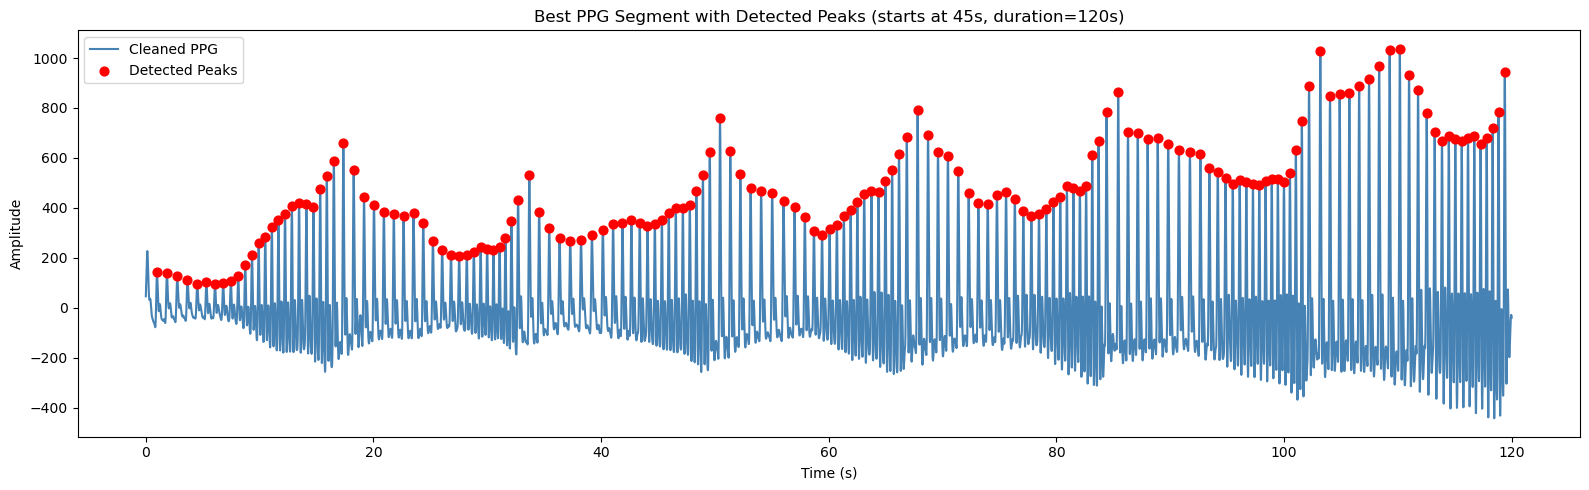

In [4]:
# Use the best-found PPG segment
ppg_trimmed = best["ppg_seg"]
ppg_peak_indices = best["ppg_peaks"]
signals_ppg = best["sig_ppg"]

print(f"PPG peaks detected: {len(ppg_peak_indices)} (segment starts at {best['abs_start']:.0f}s)")

ppg_time_trimmed = np.arange(len(ppg_trimmed)) / PPG_FS

plt.figure(figsize=(16, 5))
plt.plot(ppg_time_trimmed, signals_ppg["PPG_Clean"], color='steelblue', label='Cleaned PPG')
plt.scatter(ppg_time_trimmed[ppg_peak_indices], signals_ppg["PPG_Clean"].iloc[ppg_peak_indices],
            color='red', s=40, zorder=5, label='Detected Peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Best PPG Segment with Detected Peaks (starts at {best["abs_start"]:.0f}s, duration={RMSSD_DURATION_SEC}s)')
plt.legend()
plt.tight_layout()
plt.show()


## Process ECG Signal

ECG R-peaks detected: 162


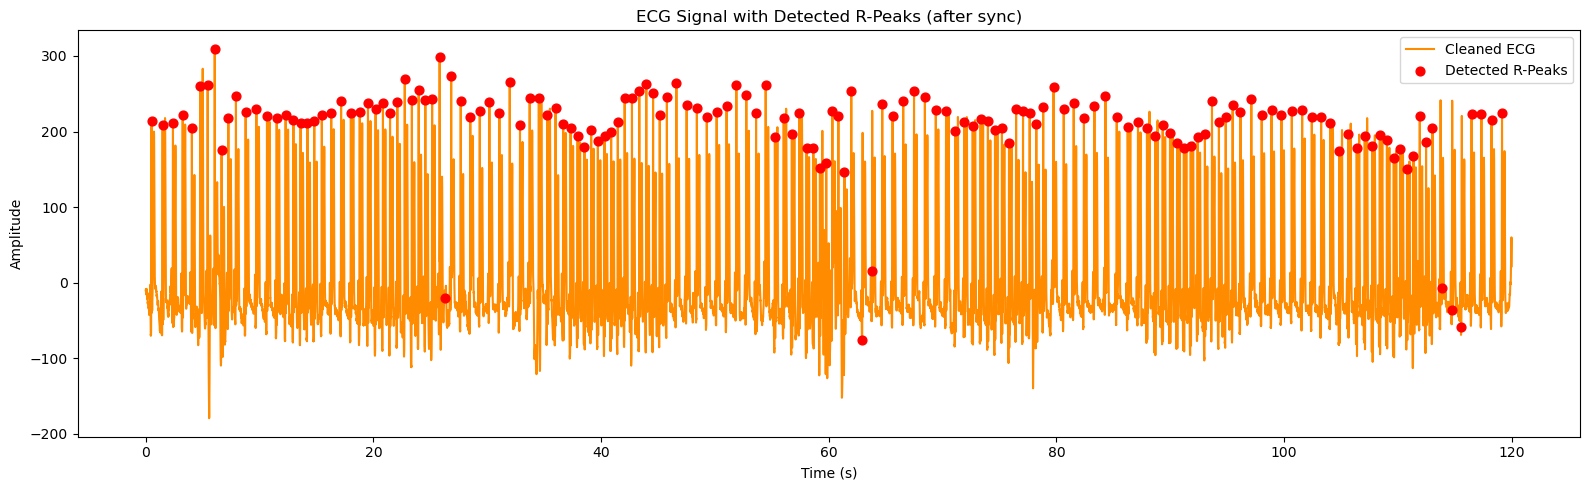

In [ ]:
# Use the best-found ECG segment
ecg_trimmed = best["ecg_seg"]
ecg_rpeaks = best["ecg_rpeaks"]
signals_ecg = best["sig_ecg"]

print(f"ECG R-peaks detected: {len(ecg_rpeaks)} (segment starts at {best['abs_start']:.0f}s)")

ecg_time_trimmed = np.arange(len(ecg_trimmed)) / ECG_FS
ecg_clean = signals_ecg["ECG_Clean"]

plt.figure(figsize=(16, 5))
plt.plot(ecg_time_trimmed, ecg_clean, color='darkorange', label='Cleaned ECG')
plt.scatter(ecg_time_trimmed[ecg_rpeaks], ecg_clean.iloc[ecg_rpeaks],
            color='red', s=40, zorder=5, label='Detected R-Peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Best ECG Segment with Detected R-Peaks (starts at {best["abs_start"]:.0f}s, duration={RMSSD_DURATION_SEC}s)')
plt.legend()
plt.tight_layout()
plt.show()


## Calculate RMSSD & Compare

In [ ]:
rmssd_ppg = best["rmssd_ppg"]
rmssd_ecg = best["rmssd_ecg"]
absolute_error = best["err"]

print("=" * 60)
print(f"  Best segment starts at: {best['abs_start']:.0f}s "
      f"(+{best['extra_offset']:.0f}s from {START_OFFSET_SEC}s offset)")
print(f"  Duration:               {RMSSD_DURATION_SEC}s")
print(f"  PPG RMSSD:              {rmssd_ppg:.2f} ms")
print(f"  ECG RMSSD:              {rmssd_ecg:.2f} ms")
print(f"  Absolute Error:         {absolute_error:.2f} ms")
print("=" * 60)

# All windows summary
all_df = pd.DataFrame([
    {
        "Start (s)": r["abs_start"],
        "PPG RMSSD (ms)": round(r["rmssd_ppg"], 2),
        "ECG RMSSD (ms)": round(r["rmssd_ecg"], 2),
        "Abs Error (ms)": round(r["err"], 2),
    }
    for r in search_results
])
all_df["Best"] = all_df["Abs Error (ms)"] == all_df["Abs Error (ms)"].min()
print("\n--- All Windows ---")
display(all_df)

# Plot absolute error across all windows
plt.figure(figsize=(10, 4))
plt.plot(all_df["Start (s)"], all_df["Abs Error (ms)"], marker='o', color='steelblue', label='Abs Error')
plt.axvline(best['abs_start'], color='red', linestyle='--', label=f'Best: {best["abs_start"]:.0f}s')
plt.xlabel('Window Start (s)')
plt.ylabel('Absolute Error (ms)')
plt.title('RMSSD Absolute Error vs. Window Start Position')
plt.legend()
plt.tight_layout()
plt.show()


  PPG RMSSD:        78.76 ms
  ECG RMSSD:        70.50 ms
  Absolute Error:   8.26 ms
  RMSE:             8.26 ms

--- Results ---


,Source,RMSSD (ms),Peaks Detected,Duration (s)
0,PPG,78.756052,161,120.0
1,ECG,70.495390,162,120.0



--- Error ---


,Metric,Value
0,Absolute Error (ms),8.260662
1,RMSE (ms),8.260662
